In [234]:
import os, glob
import numpy as np
import pandas as pd
import otter
from otter import Otter, DataFinder
from astropy.table import vstack
from astropy import units as u


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.offsetbox import AnchoredText

from multiprocessing import Pool


def print_for_copy(df):
    '''
    Print a df so that I can copy it over to the spreadsheet
    '''

    for _, row in df.iterrows():
        
        s = ''
        for col in df.columns:
            s += str(row[col]) + '\t'

        print(s)

In [2]:
otterpath = "private_otter_data"
overwrite = False

if overwrite:
    if os.path.exists(otterpath):
        for file in glob.glob(os.path.join(otterpath, "*")):
            os.remove(file)
        os.rmdir(otterpath)


    private_data = Otter.from_csvs("ecle-metadata.csv", photfile="all-photometry.csv", local_outpath=otterpath)
else:
    private_data = Otter(datadir=otterpath)

In [4]:
ecles = private_data.query(classification="ECLE", query_private=True)
len(ecles)

24

# Query ZTF (and maybe eventually ATLAS) 

and make it faster with multiprocessing

In [132]:
def download_optical_data(ecle, n=1):
    c = ecle.get_skycoord()
    data_finder = DataFinder(c.ra, c.dec, "deg", "deg", name=ecle.default_name)
    dd = ecle.get_discovery_date().mjd
    
    #ztf = data_finder.query_ztf().to_pandas()
    #ztf.to_csv(f"optical_data/ztf-{ecle.default_name}.csv")
    asassn_file = f"optical_data/asassn-{ecle.default_name}.csv"
    if os.path.exists(asassn_file):
        return
    
    try:
        asassn = data_finder.query_asassn(nthreads=n)
    except ValueError:
        return
        
    asassn.to_csv(asassn_file)

    #atlas = data_finder.query_atlas(disc_date=dd+200)
    #atlas.to_csv(f"optical_data/atlas-{ecle.default_name}.csv")

# with Pool(12) as p:
for ecle in ecles:
    download_optical_data(ecle, n=12)

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.


Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.

Pulled 1 of 1
Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.

Pulled 1 of 1
Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.

Pulled 1 of 1
Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.

Pulled 1 of 1
Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.


Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.


Welcome to ASAS-SN Skypatrol!

Current Deployment Ve

/tmp/ipykernel_157055/3144604099.py:137: RuntimeWarning: invalid value encountered in log10
  atlas_phot["mag"] = atlas_phot.apply(lambda row : -2.5*np.log10(row.uJy/atlas_zps[row.F]), axis=1)
/tmp/ipykernel_157055/3144604099.py:137: RuntimeWarning: invalid value encountered in log10
  atlas_phot["mag"] = atlas_phot.apply(lambda row : -2.5*np.log10(row.uJy/atlas_zps[row.F]), axis=1)
/home/noahf/astro-otter/otter/src/otter/io/transient.py:866: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/astro-otter/otter/src/otter/io/transient.py:866: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/astro-otter/otter/src/otter/io/transient.py:866: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/astro-otter/otter/src/otter/io/transient.py:866: UserWarning: Names have the same score! Just using the existing default_name
  warnings.

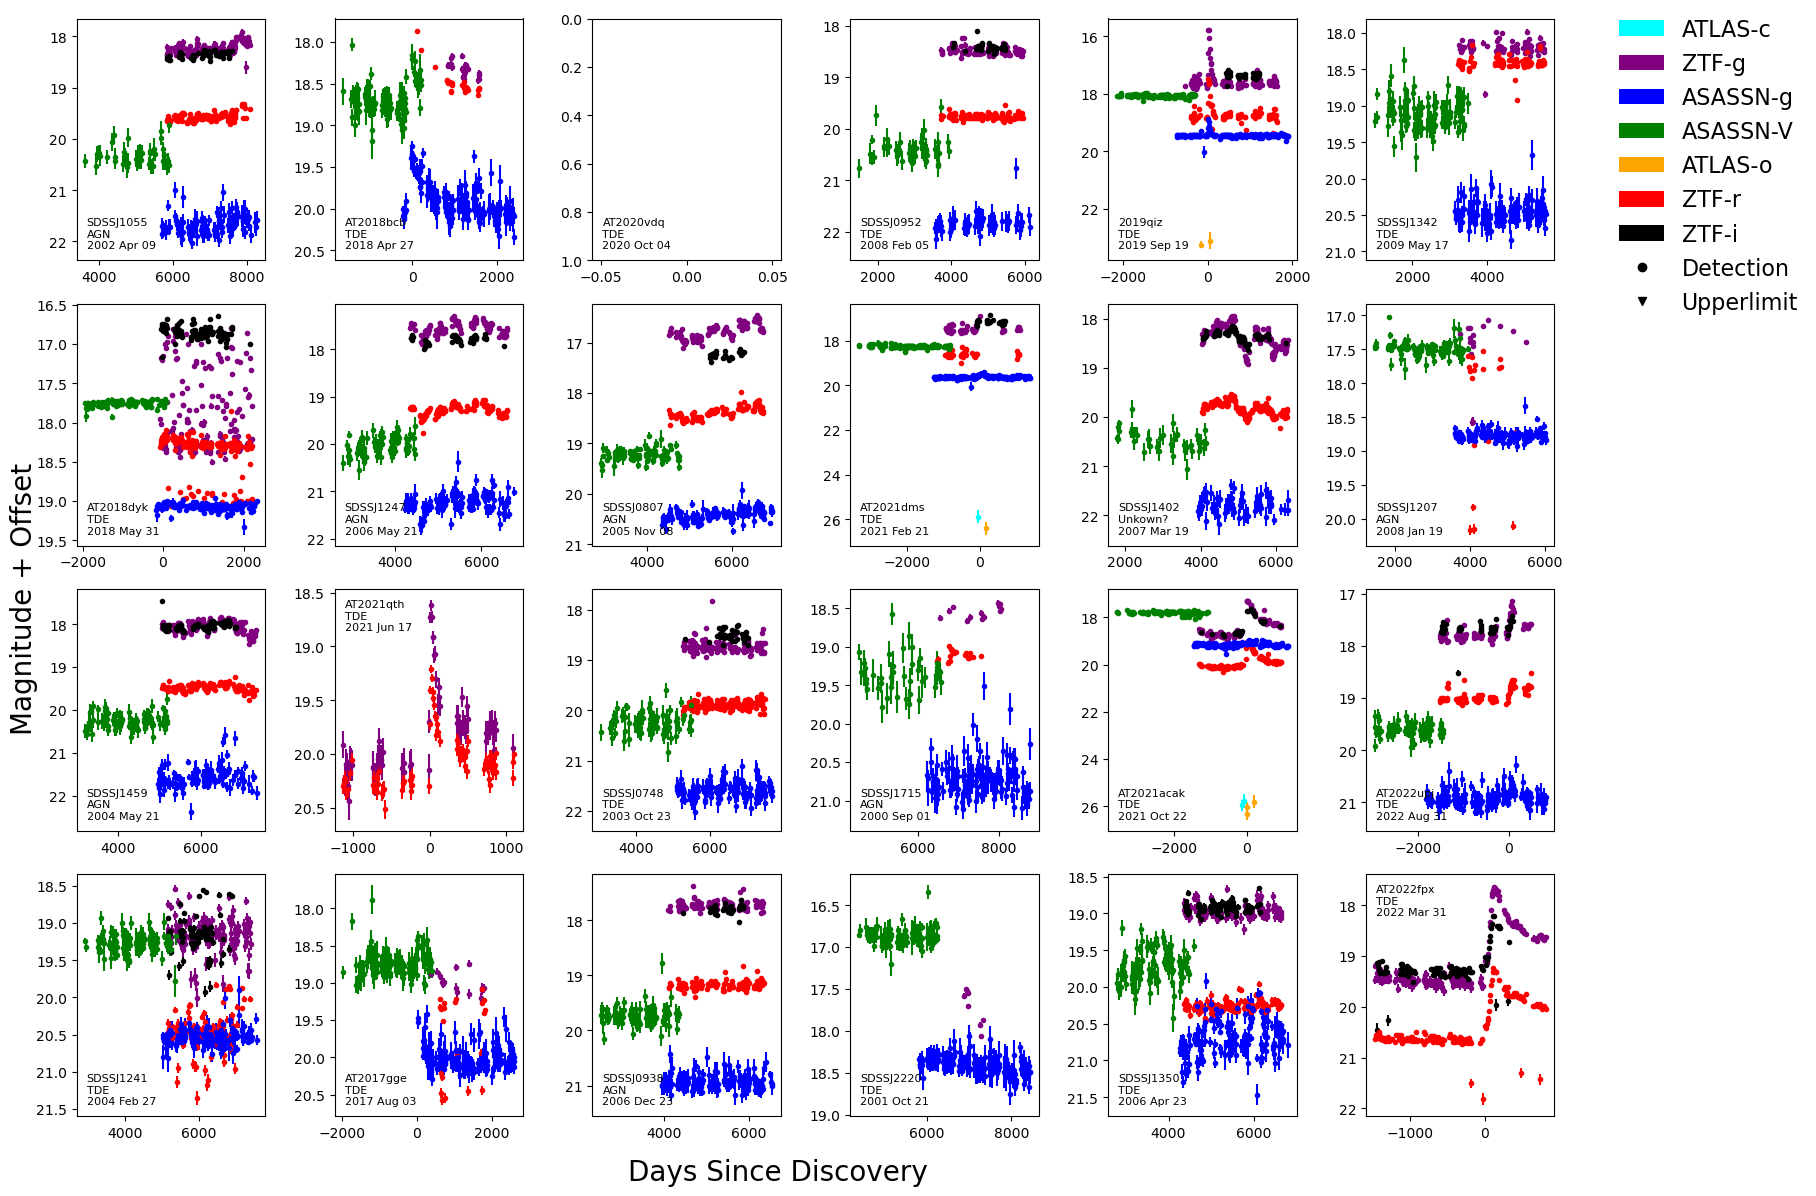

In [201]:
ztf_files = glob.glob("optical_data/ztf*csv")
fig, axs = plt.subplots(4, int(np.ceil(len(ztf_files)/4)), figsize=(16,12), sharey=False, sharex=False)
# axs[0,0].invert_yaxis()

group_by_days = 10

all_filters = {
    'ATLAS-c' : "cyan",
    'ZTF-g' : "purple", 
    'ASASSN-g' : "blue",
    'ASASSN-V' : "green",
    "ATLAS-o" : "orange",
    'ZTF-r' : "red", 
    'ZTF-i' : "k", 
}

# From the SVO filter service
atlas_zps = {
    "o" : (3631.00 * u.Jy).to(u.uJy).value,
    "c" : (3733.25 * u.Jy).to(u.uJy).value
}

default_pos = "lower left"

label_pos_override = {
    "AT2021qth" : "upper left",
    "AT2022fpx" : "upper left"
}

for ax, datafile in zip(axs.flatten(), ztf_files):
    tname = os.path.basename(datafile).split(".")[0].replace("ztf-", "")
    df = pd.read_csv(datafile)
    asassn_file = datafile.replace("ztf", "asassn")
    atlas_file = datafile.replace("ztf", "atlas")
    
    ax.invert_yaxis()

    # Figure out if it is an AGN or TDE
    classes = private_data.query(names=tname, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    # get the discovery date
    disc_date = private_data.query(names=tname, query_private=True)[0].get_discovery_date()

    if tname in label_pos_override:
        label_pos = label_pos_override[tname]
    else:
        label_pos = default_pos
    
    at = AnchoredText(
        f"{tname.replace('_','')}\n{ecle_class}\n{disc_date.strftime('%Y %b %d')}", 
        label_pos, 
        frameon=False, 
        prop=dict(fontsize=8)
    )
    ax.add_artist(at)

    ### PLOT ZTF DATA FIRST
    ii = 0
    di = 1
    for filt, grp in df.groupby("filtercode"):

        grps = grp.groupby(
            pd.cut(
                df.mjd, 
                int((df.mjd.max() - df.mjd.min()) // group_by_days)
            ),
            observed = True
        )
        
        grouped_data = grps[["mjd", "mag", "limitmag"]].median()
        err = grps.magerr.median() #np.sqrt(grps.magerr.mean()**2 + grps.mag.std()**2)

        isuplim = grouped_data.mag > grouped_data.limitmag

        filtname = f"ZTF-{filt[1]}"        
        line = ax.errorbar(
            grouped_data.mjd[~isuplim] - disc_date.mjd, 
            grouped_data.mag[~isuplim]+ii, 
            yerr=err[~isuplim], 
            marker='.', 
            linestyle='none', 
            color=all_filters[filtname]
        )
        # ax.errorbar(
        #     grouped_data.mjd[isuplim] - disc_date.mjd, 
        #     grouped_data.mag[isuplim]+ii, 
        #     marker='v', 
        #     linestyle='none', 
        #     color=line[0].get_color()
        # )
        ii += di
    
    if os.path.exists(asassn_file):
        ### THEN ASASSN
        asassn = pd.read_csv(asassn_file)
        asassn["mjd"] = [Time(t, format="jd").mjd for t in asassn.jd]
        for filt, grp in asassn.groupby("phot_filter"):
    
            grps = grp.groupby(
                pd.cut(
                    asassn.mjd, 
                    int((asassn.mjd.max() - asassn.mjd.min()) // group_by_days)
                ),
                observed = True
            )
            
            grouped_data = grps[["mjd", "mag", "limit"]].median()
            err = grps.mag_err.median() #np.sqrt(grps.magerr.mean()**2 + grps.mag.std()**2)
    
            isuplim = err > np.log(10) / (3 * 2.5)
    
            filtname = f"ASASSN-{filt}"
            line = ax.errorbar(
                grouped_data.mjd[~isuplim] - disc_date.mjd, 
                grouped_data.mag[~isuplim]+ii, 
                yerr=err[~isuplim], 
                marker='.', 
                linestyle='none', 
                color=all_filters[filtname]
            )
            # ax.errorbar(
            #     grouped_data.mjd[isuplim] - disc_date.mjd, 
            #     grouped_data.mag[isuplim]+ii, 
            #     marker='v', 
            #     linestyle='none', 
            #     color=line[0].get_color()
            # )
            ii += di

    # FINALLY ATLAS
    if os.path.exists(atlas_file):
        atlas_phot = pd.read_csv(atlas_file)        
        atlas_phot["mag"] = atlas_phot.apply(lambda row : -2.5*np.log10(row.uJy/atlas_zps[row.F]), axis=1)
        atlas_phot["mag_err"] = atlas_phot.apply(lambda row : np.abs(np.log(10) / 2.5) * row.duJy/row.uJy, axis=1)
        atlas_phot["upperlimit"] = atlas_phot.apply(lambda row : row.uJy < row.duJy*3, axis=1)
        atlas_phot.mjd = atlas_phot.mjd.astype(float)
        
        for filt, grp in atlas_phot.groupby("F"):

            # grps = grp.groupby(
            #     pd.cut(
            #         atlas.mjd, 
            #         int((atlas.mjd.max() - atlas.mjd.min()) // group_by_days)
            #     ),
            #     observed = True
            # )
            
            # grouped_data = grps[["mjd", "mag"]].median()
            # err = grps.mag_err.median() #np.sqrt(grps.magerr.mean()**2 + grps.mag.std()**2)

            # isuplim = grps.upperlimit.all()
            grouped_data = grp
            err = grp.mag_err
            isuplim = grouped_data.upperlimit
            
            filtname = f"ATLAS-{filt}"
            line = ax.errorbar(
                grouped_data.mjd[~isuplim] - disc_date.mjd, 
                grouped_data.mag[~isuplim]+ii, 
                yerr=err[~isuplim], 
                marker='.', 
                linestyle='none', 
                color=all_filters[filtname]
            )
            # ax.errorbar(
            #     grouped_data.mjd[isuplim] - disc_date.mjd, 
            #     grouped_data.mag[isuplim]+ii, 
            #     marker='v', 
            #     linestyle='none', 
            #     color=line[0].get_color()
            # )
            ii += di

fig.supxlabel("Days Since Discovery", fontsize=20)
fig.supylabel("Magnitude + Offset", fontsize=20)
fig.legend(
    handles = [
        Patch(
            facecolor=c,
            label=lab
        ) for lab, c in all_filters.items()
    ] + [
        Line2D([0],[0],linestyle='none',marker='o',label="Detection", color='k'),
        Line2D([0],[0],linestyle='none',marker='v',label="Upperlimit", color='k')
    ],
    bbox_to_anchor = (1.15,1),
    frameon = False,
    fontsize=16
)
fig.tight_layout()

In [233]:
phot = {
    "name" : [], 
    "day" : [], 
    "date" : [], 
    "date_format" : [], 
    "filter" : [], 
    "filter_eff" : [], 
    "filter_eff_units" : [], 
    "flux" : [], 
    "flux_err" : [], 
    "flux_unit" : [], 
    "upperlimit" : [],
    "telescope" : []
}

eff_wave = {
    # ZTF
    "zg" : 4746.48,
    "zr" : 6366.38,
    "zi" : 7829.03,

    # ASASSN
    "g" : otter.util.FILTER_MAP_WAVE["g"]*10,
    "V" : otter.util.FILTER_MAP_WAVE["V"]*10,
    
    # ATLAS
    "c" : 5182.42,
    "o" : 6629.82
}

eff_wave_unit = "AA"

for ax, datafile in zip(axs.flatten(), ztf_files):
    tname = os.path.basename(datafile).split(".")[0].replace("ztf-", "")
    
    # reorganize ZTF files
    df = pd.read_csv(datafile)
    phot["name"] += [tname]*len(df)
    phot["day"] += df.mjd.tolist()
    phot["date"] += df.mjd.tolist()
    phot["date_format"] += ["MJD"]*len(df)
    phot["filter"] += [f[1] for f in df.filtercode]
    phot["filter_eff"] += df.filtercode.replace(eff_wave).tolist()
    phot["filter_eff_units"] += [eff_wave_unit]*len(df)
    phot["flux"] += df.mag.tolist()
    phot["flux_err"] += df.magerr.tolist()
    phot["flux_unit"] += ["mag(AB)"]*len(df)
    phot["upperlimit"] += (df.mag > df.limitmag).tolist()
    phot["telescope"] += ["ZTF"]*len(df)
    
    asassn_file = datafile.replace("ztf", "asassn")
    if os.path.exists(asassn_file):
        asassn = pd.read_csv(asassn_file)

        phot["name"] += [tname]*len(asassn)
        phot["day"] += asassn.jd.tolist()
        phot["date"] += asassn.jd.tolist()
        phot["date_format"] += ["JD"]*len(asassn)
        phot["filter"] += asassn.phot_filter.tolist()
        phot["filter_eff"] += asassn.phot_filter.replace(eff_wave).tolist()
        phot["filter_eff_units"] += [eff_wave_unit]*len(asassn)
        phot["flux"] += asassn.mag.tolist()
        phot["flux_err"] += asassn.mag_err.tolist()
        phot["flux_unit"] += ["mag(AB)"]*len(asassn)
        phot["upperlimit"] += (asassn.mag > asassn.limit).tolist()
        phot["telescope"] += ["ASASSN"]*len(asassn)
        
    
    atlas_file = datafile.replace("ztf", "atlas")
    if os.path.exists(atlas_file):
        atlas = pd.read_csv(atlas_file)

        phot["name"] += [tname]*len(atlas)
        phot["day"] += atlas.mjd.tolist()
        phot["date"] += atlas.mjd.tolist()
        phot["date_format"] += ["MJD"]*len(atlas)
        phot["filter"] += atlas.F.tolist()
        phot["filter_eff"] += atlas.F.replace(eff_wave).tolist()
        phot["filter_eff_units"] += [eff_wave_unit]*len(atlas)
        phot["flux"] += atlas.uJy.tolist()
        phot["flux_err"] += atlas.duJy.tolist()
        phot["flux_unit"] += ["uJy"]*len(atlas)
        phot["upperlimit"] += (atlas.uJy > 3*atlas.duJy).tolist()
        phot["telescope"] += ["ATLAS"] * len(atlas)

pd.DataFrame(phot).to_csv("ecle-optical-data-for-otter.csv", index=False)